1) This is the 1st code to connect to your drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)




MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os
MODEL_PATH = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/complex_iterative_unet_final.keras"
print(os.path.exists(MODEL_PATH))  # Should print True if the file exists

True


from google.colab import drive
drive.mount('/content/drive')

2) This is the code to check whether the path consists chase or not if chase exist then what are the folders inside the chase


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed"

# Check if the dataset folder exists and is not empty
if os.path.isdir(dataset_path) and os.listdir(dataset_path):
    print("Files in dataset:", os.listdir(dataset_path))
else:
    print("Dataset folder is empty or does not exist.")

Files in dataset: ['train_images', 'train_masks', 'test_images', 'test_masks', 'augmented_train_images', 'augmented_train_masks', 'logs', 'hanet_finished.keras', 'hanet_better_final.keras', 'retinal_vessel_segmentation_saunet.keras', 'saunet.keras', 'complex_iterative_unet_final.keras', 'Copy of complex_iterative_unet_final.keras']


3) comparing 1st mannual and 2nd manual since those both are almost similar we are using 1st manual

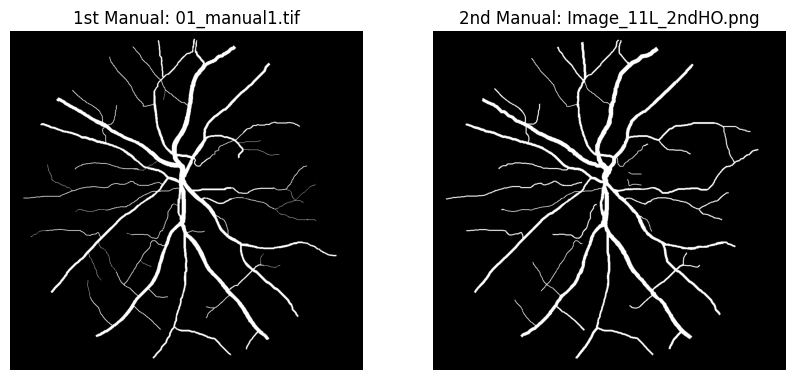

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Define paths
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase"
MASKS_1ST = os.path.join(BASE_DIR, "test", "1st_manual")
MASKS_2ND = os.path.join(BASE_DIR, "test", "2nd_manual")

# Pick one file from each set (change if needed)
file_1st = "01_manual1.tif"  # Update if needed
file_2nd = "Image_11L_2ndHO.png"  # Update if needed

# Load images
mask_1st = cv2.imread(os.path.join(MASKS_1ST, file_1st), cv2.IMREAD_GRAYSCALE)
mask_2nd = cv2.imread(os.path.join(MASKS_2ND, file_2nd), cv2.IMREAD_GRAYSCALE)

# Show images
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(mask_1st, cmap="gray")
axs[0].set_title(f"1st Manual: {file_1st}")
axs[0].axis("off")

axs[1].imshow(mask_2nd, cmap="gray")
axs[1].set_title(f"2nd Manual: {file_2nd}")
axs[1].axis("off")

plt.show()


3) preprocessing where images are converted into grayscale and 1st_manual images are resized

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm  # Progress bar
import shutil  # For creating new directories

# Define paths (Modify if needed)
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase"  # Base dataset directory
TRAIN_IMG_DIR = os.path.join(BASE_DIR, "training", "images")  # Training images
TRAIN_MASK_DIR = os.path.join(BASE_DIR, "training", "1st_manual")  # Training masks
TEST_IMG_DIR = os.path.join(BASE_DIR, "test", "images")  # Test images
TEST_MASK_DIR = os.path.join(BASE_DIR, "test", "1st_manual")  # Test masks

# Output directories (Processed images will be saved here)
OUTPUT_TRAIN_IMG = os.path.join(BASE_DIR, "preprocessed", "train_images")
OUTPUT_TRAIN_MASK = os.path.join(BASE_DIR, "preprocessed", "train_masks")
OUTPUT_TEST_IMG = os.path.join(BASE_DIR, "preprocessed", "test_images")
OUTPUT_TEST_MASK = os.path.join(BASE_DIR, "preprocessed", "test_masks")

# Ensure output directories exist (delete existing ones if needed)
for dir_path in [OUTPUT_TRAIN_IMG, OUTPUT_TRAIN_MASK, OUTPUT_TEST_IMG, OUTPUT_TEST_MASK]:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)
    os.makedirs(dir_path)


def preprocess_image(img_path, target_size=(512, 512), apply_clahe=True):
    """Loads an image, resizes it, applies CLAHE to grayscale, and normalizes pixel values."""
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Error reading image: {img_path}")
    img = cv2.resize(img, target_size)

    # Convert to grayscale
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply CLAHE for contrast enhancement
    if apply_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray_img = clahe.apply(gray_img)

    # Normalize to range [0, 1]
    gray_img = gray_img / 255.0
    return gray_img


def preprocess_mask(mask_path, target_size=(512, 512)):
    """Loads a mask, resizes it, and ensures binary format (0 and 1 only)."""
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Error reading mask: {mask_path}")
    mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
    mask = (mask > 127).astype(np.uint8)
    return mask


def normalize_filename(filename, file_type):
    """
    Normalizes filename based on type.
    For images, remove 'test'; for masks, remove 'manual1'.
    Then remove underscores/hyphens and convert to lowercase.
    """
    base = os.path.splitext(filename)[0]
    if file_type == "img":
        base = base.replace("test", "")
    elif file_type == "mask":
        base = base.replace("manual1", "")
    base = base.replace("_", "").replace("-", "").strip().lower()
    return base


def process_dataset(image_dir, mask_dir, output_img_dir, output_mask_dir):
    """
    Preprocesses images and masks by matching based on normalized filenames.
    """
    # Build dictionaries with normalized filenames as keys
    image_files = {normalize_filename(f, "img"): f for f in os.listdir(image_dir)}
    mask_files = {normalize_filename(f, "mask"): f for f in os.listdir(mask_dir)}

    # Debug: print normalized filename dictionaries
    print("Normalized image filenames:")
    for norm, orig in image_files.items():
        print(f"  {norm}: {orig}")
    print("Normalized mask filenames:")
    for norm, orig in mask_files.items():
        print(f"  {norm}: {orig}")

    # Get common keys (matching pairs)
    common_files = set(image_files.keys()) & set(mask_files.keys())
    print(f"\nFound {len(common_files)} matching image-mask pairs in {image_dir} and {mask_dir}")

    if len(common_files) == 0:
        print(f"⚠️ No matching images & masks found in {image_dir} and {mask_dir}")
        return

    for base_name in tqdm(common_files, total=len(common_files)):
        img_filename = image_files[base_name]
        mask_filename = mask_files[base_name]

        img_path = os.path.join(image_dir, img_filename)
        mask_path = os.path.join(mask_dir, mask_filename)

        # Preprocess image and mask
        processed_img = preprocess_image(img_path)
        processed_mask = preprocess_mask(mask_path)

        # Save preprocessed images and masks (back to 8-bit)
        cv2.imwrite(os.path.join(output_img_dir, img_filename), (processed_img * 255).astype(np.uint8))
        cv2.imwrite(os.path.join(output_mask_dir, mask_filename), (processed_mask * 255).astype(np.uint8))

    print(f"\nPreprocessing completed! Processed files saved in:")
    print(f"  Images: {output_img_dir}")
    print(f"  Masks: {output_mask_dir}")


# Run preprocessing for train and test datasets
print("Processing Training Data...")
process_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, OUTPUT_TRAIN_IMG, OUTPUT_TRAIN_MASK)

print("\nProcessing Test Data...")
process_dataset(TEST_IMG_DIR, TEST_MASK_DIR, OUTPUT_TEST_IMG, OUTPUT_TEST_MASK)


Processing Training Data...
Normalized image filenames:
  07: 07_test.tif
  11: 11_test.tif
  01: 01_test.tif
  15: 15_test.tif
  03: 03_test.tif
  14: 14_test.tif
  10: 10_test.tif
  13: 13_test.tif
  04: 04_test.tif
  06: 06_test.tif
  17: 17_test.tif
  12: 12_test.tif
  02: 02_test.tif
  18: 18_test.tif
  19: 19_test.tif
  08: 08_test.tif
  09: 09_test.tif
  05: 05_test.tif
  16: 16_test.tif
  20: 20_test.tif
Normalized mask filenames:
  12: 12_manual1.tif
  20: 20_manual1.tif
  07: 07_manual1.tif
  13: 13_manual1.tif
  15: 15_manual1.tif
  02: 02_manual1.tif
  19: 19_manual1.tif
  09: 09_manual1.tif
  08: 08_manual1.tif
  17: 17_manual1.tif
  01: 01_manual1.tif
  18: 18_manual1.tif
  03: 03_manual1.tif
  11: 11_manual1.tif
  16: 16_manual1.tif
  05: 05_manual1.tif
  04: 04_manual1.tif
  06: 06_manual1.tif
  10: 10_manual1.tif
  14: 14_manual1.tif

Found 20 matching image-mask pairs in /content/drive/MyDrive/Colab_Notebooks/chase/training/images and /content/drive/MyDrive/Colab_Note

100%|██████████| 20/20 [00:25<00:00,  1.30s/it]



Preprocessing completed! Processed files saved in:
  Images: /content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/train_images
  Masks: /content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/train_masks

Processing Test Data...
Normalized image filenames:
  05: 05_test.tif
  04: 04_test.tif
  08: 08_test.tif
  07: 07_test.tif
  01: 01_test.tif
  02: 02_test.tif
  06: 06_test.tif
  03: 03_test.tif
Normalized mask filenames:
  03: 03_manual1.tif
  04: 04_manual1.tif
  06: 06_manual1.tif
  05: 05_manual1.tif
  02: 02_manual1.tif
  01: 01_manual1.tif
  08: 08_manual1.tif
  07: 07_manual1.tif

Found 8 matching image-mask pairs in /content/drive/MyDrive/Colab_Notebooks/chase/test/images and /content/drive/MyDrive/Colab_Notebooks/chase/test/1st_manual


100%|██████████| 8/8 [00:08<00:00,  1.06s/it]


Preprocessing completed! Processed files saved in:
  Images: /content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/test_images
  Masks: /content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/test_masks


4) This is the augmentation code for all the preprocessed images


In [ ]:
import os
import cv2
import numpy as np
import albumentations as A
from tqdm import tqdm
import shutil

# Define paths for preprocessed data
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/"
TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train_images")
TRAIN_MASK_DIR = os.path.join(BASE_DIR, "train_masks")

# Define paths for augmented data
AUG_TRAIN_IMG_DIR = os.path.join(BASE_DIR, "augmented_train_images")
AUG_TRAIN_MASK_DIR = os.path.join(BASE_DIR, "augmented_train_masks")

# Ensure output directories exist
for dir_path in [AUG_TRAIN_IMG_DIR, AUG_TRAIN_MASK_DIR]:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)  # Delete old files
    os.makedirs(dir_path)  # Create new empty folders

# ✅ Define augmentation transformations with `mask` mode
augmentation = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
], additional_targets={"mask": "mask"})  # Preserve binary mask structure

def normalize_filename(filename):
    """Extracts the numeric identifier from filenames to match images & masks."""
    return filename.replace("_test", "").replace("_manual1", "").split(".")[0]

def preprocess_image(img_path):
    """Loads an image, applies CLAHE, and normalizes to range [0,1]."""
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Error reading image: {img_path}")

    # Convert to grayscale
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_img = clahe.apply(gray_img)

    # Normalize to [0,1]
    return gray_img / 255.0

def preprocess_mask(mask_path):
    """Loads a mask and ensures it is binary (values 0 and 255 only)."""
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Error reading mask: {mask_path}")

    # Convert to binary (0 or 255)
    return (mask > 127).astype(np.uint8) * 255

def augment_dataset(image_dir, mask_dir, output_img_dir, output_mask_dir, augmentations=3):
    """Applies augmentation to fundus images and masks, then saves them."""

    # Get images and masks with normalized filenames
    image_files = {normalize_filename(f): f for f in os.listdir(image_dir)}
    mask_files = {normalize_filename(f): f for f in os.listdir(mask_dir)}

    # Find common identifiers (images & masks must match)
    common_files = set(image_files.keys()) & set(mask_files.keys())

    if not common_files:
        print("⚠️ No matching image-mask pairs found. Check filenames and folder structure.")
        return

    for file_name in tqdm(common_files, total=len(common_files)):
        img_path = os.path.join(image_dir, image_files[file_name])
        mask_path = os.path.join(mask_dir, mask_files[file_name])

        # Preprocess the image and mask
        img = preprocess_image(img_path)  # CLAHE grayscale, normalized
        mask = preprocess_mask(mask_path)  # Binary mask (0 or 255)

        # Convert back to 8-bit grayscale for saving
        img_8bit = (img * 255).astype(np.uint8)

        # Save original images in the augmented dataset as well
        cv2.imwrite(os.path.join(output_img_dir, image_files[file_name]), img_8bit)
        cv2.imwrite(os.path.join(output_mask_dir, mask_files[file_name]), mask)

        # Generate multiple augmentations per image
        for i in range(augmentations):
            augmented = augmentation(image=img_8bit, mask=mask)
            aug_img = augmented["image"]
            aug_mask = augmented["mask"]

            # 🔹 Ensure mask remains binary (0 or 255)
            aug_mask = (aug_mask > 127).astype(np.uint8) * 255

            # Save augmented image and mask
            aug_img_filename = f"aug_{i}_{image_files[file_name]}"
            aug_mask_filename = f"aug_{i}_{mask_files[file_name]}"
            cv2.imwrite(os.path.join(output_img_dir, aug_img_filename), aug_img)
            cv2.imwrite(os.path.join(output_mask_dir, aug_mask_filename), aug_mask)

    print(f"✅ Augmentation completed! Files saved in {output_img_dir} and {output_mask_dir}")

# Run augmentation only for the training dataset
print("Augmenting Training Data...")
augment_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, AUG_TRAIN_IMG_DIR, AUG_TRAIN_MASK_DIR)


<ipython-input-5-6766017dddb1>:30: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),


Augmenting Training Data...


100%|██████████| 20/20 [00:08<00:00,  2.43it/s]

✅ Augmentation completed! Files saved in /content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/augmented_train_images and /content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/augmented_train_masks


------- ITERNET MODEL

In [ ]:
import os
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers, mixed_precision
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split

# Enable mixed precision
mixed_precision.set_global_policy('mixed_float16')

# Define paths
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/"
AUG_TRAIN_IMG_DIR = os.path.join(BASE_DIR, "augmented_train_images")
AUG_TRAIN_MASK_DIR = os.path.join(BASE_DIR, "augmented_train_masks")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
TEST_MASK_DIR = os.path.join(BASE_DIR, "test_masks")

# Model parameters
IMG_SIZE = (512, 512)
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 1e-4
ITERATIONS = 3
DROPOUT_RATE = 0.3

# Prepare lists of file paths for images and masks
def get_file_paths(image_dir, mask_dir):
    image_files = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir)])
    mask_files = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir)])
    return image_files, mask_files

train_img_paths, train_mask_paths = get_file_paths(AUG_TRAIN_IMG_DIR, AUG_TRAIN_MASK_DIR)
# Test paths are defined but not used for evaluation
test_img_paths, test_mask_paths = get_file_paths(TEST_IMG_DIR, TEST_MASK_DIR)

# Split training data into train and validation sets
(train_img_paths, val_img_paths,
 train_mask_paths, val_mask_paths) = train_test_split(train_img_paths, train_mask_paths, test_size=0.2, random_state=42)

# Define a function to load and preprocess an image and its mask
def parse_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
    mask = tf.image.resize(mask, IMG_SIZE)
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask

# Create tf.data datasets with proper input-target separation
def create_dataset(img_paths, mask_paths, batch_size, is_training=True):
    dataset = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    dataset = dataset.map(lambda img, mask: (parse_image(img, mask)[0], parse_image(img, mask)[1]),
                          num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.ignore_errors()  # Handle errors gracefully
    if is_training:
        dataset = dataset.shuffle(buffer_size=100)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_dataset(train_img_paths, train_mask_paths, BATCH_SIZE, is_training=True)
val_dataset = create_dataset(val_img_paths, val_mask_paths, BATCH_SIZE, is_training=False)
# Test dataset is created but not used for evaluation
test_dataset = create_dataset(test_img_paths, test_mask_paths, BATCH_SIZE, is_training=False)

# Calculate steps per epoch and validation steps
train_steps = len(train_img_paths) // BATCH_SIZE
val_steps = len(val_img_paths) // BATCH_SIZE

# Ensure at least 1 step if dataset is small
train_steps = max(train_steps, 1)
val_steps = max(val_steps, 1)

# Attention Gate
def attention_gate(g, s, filters):
    wg = layers.Conv2D(filters, (1, 1), padding='same')(g)
    ws = layers.Conv2D(filters, (1, 1), padding='same')(s)
    out = layers.Activation('relu')(layers.Add()([wg, ws]))
    out = layers.Conv2D(1, (1, 1), padding='same')(out)
    out = layers.Activation('sigmoid')(out)
    return layers.Multiply()([s, out])

# Residual Block
def residual_block(x, filters, kernel_size=(3, 3)):
    r = layers.Conv2D(filters, kernel_size, padding='same', activation='relu')(x)
    r = layers.BatchNormalization()(r)
    r = layers.Conv2D(filters, kernel_size, padding='same')(r)
    r = layers.BatchNormalization()(r)
    return layers.Add()([x, r])

# Complex Iterative U-Net model
def complex_iterative_unet_model(input_size=(512, 512, 1), iterations=ITERATIONS):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    c1 = residual_block(c1, 64)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(p1)
    c2 = residual_block(c2, 128)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(p2)
    c3 = residual_block(c3, 256)
    c3 = layers.BatchNormalization()(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(p3)
    c4 = residual_block(c4, 512)
    c4 = layers.BatchNormalization()(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, (3, 3), dilation_rate=2, padding='same', activation='relu')(p4)
    c5 = residual_block(c5, 1024)
    c5 = layers.Dropout(DROPOUT_RATE)(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    att6 = attention_gate(u6, c4, 512)
    u6 = layers.concatenate([u6, att6])
    c6 = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(u6)
    c6 = residual_block(c6, 512)
    c6 = layers.BatchNormalization()(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    att7 = attention_gate(u7, c3, 256)
    u7 = layers.concatenate([u7, att7])
    c7 = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(u7)
    c7 = residual_block(c7, 256)
    c7 = layers.BatchNormalization()(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    att8 = attention_gate(u8, c2, 128)
    u8 = layers.concatenate([u8, att8])
    c8 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(u8)
    c8 = residual_block(c8, 128)
    c8 = layers.BatchNormalization()(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    att9 = attention_gate(u9, c1, 64)
    u9 = layers.concatenate([u9, att9])
    c9 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(u9)
    c9 = residual_block(c9, 64)
    c9 = layers.BatchNormalization()(c9)

    # Initial prediction
    initial_pred = layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same')(c9)

    # Iterative refinement with ConvLSTM
    refinement_input = layers.concatenate([inputs, initial_pred])
    refinement_input_expanded = layers.Lambda(lambda x: tf.expand_dims(x, axis=1))(refinement_input)
    refinement = layers.ConvLSTM2D(64, (3, 3), padding='same', return_sequences=False)(refinement_input_expanded)

    for _ in range(iterations - 1):
        att_ref = attention_gate(refinement, inputs, 64)
        att_ref_expanded = layers.Lambda(lambda x: tf.expand_dims(x, axis=1))(att_ref)
        refinement = layers.ConvLSTM2D(64, (3, 3), padding='same', return_sequences=False)(att_ref_expanded)

    # Multi-scale output fusion
    out1 = layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same')(refinement)
    out2 = layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same')(c9)
    outputs = layers.Average()([out1, out2])

    # Ensure output is float32 for mixed precision compatibility
    outputs = layers.Activation('sigmoid', dtype='float32')(outputs)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Combined Dice + BCE Loss
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def combined_loss(y_true, y_pred):
    dice = dice_loss(y_true, y_pred)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.7 * dice + 0.3 * bce

# Build and compile model
model = complex_iterative_unet_model(input_size=(IMG_SIZE[0], IMG_SIZE[1], 1), iterations=ITERATIONS)
model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
              loss=combined_loss,
              metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2),
                       tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6),
    ModelCheckpoint(os.path.join(BASE_DIR, "complex_iterative_unet_best.keras"),
                    monitor='val_loss', save_best_only=True)
]

# Train the model
print("Training Complex Iterative U-Net...")
history = model.fit(train_dataset,
                    steps_per_epoch=train_steps,
                    epochs=EPOCHS,
                    validation_data=val_dataset,
                    validation_steps=val_steps,
                    callbacks=callbacks,
                    verbose=1)

# Save the final model in Keras format
model.save(os.path.join(BASE_DIR, "complex_iterative_unet_final.keras"))
print("Model saved successfully in Keras format!")

Training Complex Iterative U-Net...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_3397']
Received: inputs=Tensor(shape=(None, 512, 512, 1))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


8/8 ━━━━━━━━━━━━━━━━━━━━ 56s 7s/step
Epoch 2/100


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: 
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: learning_rate.
  callback.on_epoch_end(epoch, logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Epoch 13/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
Epoch 14/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
Epoch 15/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step
Epoch 16/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Epoch 17/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
Epoch 18/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Epoch 19/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Epoch 20/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
Epoch 21/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step


LOADING THE MODEL

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.layers import Lambda
from tensorflow.keras.models import load_model

# Ensure Lambda has output_shape
def my_lambda_function(x):
    return x[:, :, :, 0]  # Example operation

lambda_layer = Lambda(my_lambda_function, output_shape=(512, 512, 1))


# Define custom layers and loss functions
def attention_gate(g, s, filters):
    wg = tf.keras.layers.Conv2D(filters, (1, 1), padding='same')(g)
    ws = tf.keras.layers.Conv2D(filters, (1, 1), padding='same')(s)
    out = tf.keras.layers.Activation('relu')(tf.keras.layers.Add()([wg, ws]))
    out = tf.keras.layers.Conv2D(1, (1, 1), padding='same')(out)
    out = tf.keras.layers.Activation('sigmoid')(out)
    return tf.keras.layers.Multiply()([s, out])

def residual_block(x, filters, kernel_size=(3, 3)):
    r = tf.keras.layers.Conv2D(filters, kernel_size, padding='same', activation='relu')(x)
    r = tf.keras.layers.BatchNormalization()(r)
    r = tf.keras.layers.Conv2D(filters, kernel_size, padding='same')(r)
    r = tf.keras.layers.BatchNormalization()(r)
    return tf.keras.layers.Add()([x, r])

def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def combined_loss(y_true, y_pred):
    dice = dice_loss(y_true, y_pred)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.7 * dice + 0.3 * bce

# Define a dummy 'Cast' layer to handle mixed precision issue
class CastLayer(tf.keras.layers.Layer):
    def __init__(self, dtype='float32', **kwargs):
        super().__init__(**kwargs)
        self.target_dtype = dtype

    def call(self, inputs):
        return tf.cast(inputs, dtype=self.target_dtype)

    def get_config(self):
        config = super().get_config()
        config.update({"dtype": self.target_dtype})
        return config

# Define path to saved model
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/"
MODEL_PATH = os.path.join(BASE_DIR, "complex_iterative_unet_final.h5")

def custom_lambda_function(x):
    return x  # Adjust this based on what your Lambda function does in the original model

custom_objects = {
    "attention_gate": attention_gate,
    "residual_block": residual_block,
    "combined_loss": combined_loss,
    "dice_loss": dice_loss,
    "Cast": CastLayer,  # Custom fix for 'Cast' layer issue
    "Lambda": Lambda(custom_lambda_function),  # Register Lambda layer properly
}

# Load the model in a safe way (without execution)
model = load_model(MODEL_PATH, custom_objects=custom_objects, compile=False)
model.summary()

print("Model loaded successfully!")


NotImplementedError: Exception encountered when calling Lambda.call().

[1mWe could not automatically infer the shape of the Lambda's output. Please specify the `output_shape` argument for this Lambda layer.[0m

Arguments received by Lambda.call():
  • args=('<KerasTensor shape=(None, 512, 512, 2), dtype=float16, sparse=False, name=keras_tensor_235>',)
  • kwargs={'mask': 'None'}

TEST DATA GENERATOR

In [ ]:
import os
import cv2
import numpy as np

# Test Dataset Paths
TEST_IMG_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/test_images"
TEST_MASK_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/test_masks"
IMG_HEIGHT, IMG_WIDTH = 256, 256  # Ensure it matches training dimensions
BATCH_SIZE = 1  # Use batch size 1 for evaluation

# Function to Load and Preprocess Test Data
def test_data_generator(image_dir, mask_dir, batch_size):
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))

    valid_files = []
    for img_file, mask_file in zip(image_files, mask_files):
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)

        if os.path.exists(img_path) and os.path.exists(mask_path):
            valid_files.append((img_path, mask_path))
        else:
            print(f"⚠️ Skipping missing file: {img_path} or {mask_path}")

    if not valid_files:
        raise ValueError("❌ No valid image-mask pairs found! Check file paths.")

    while True:
        for i in range(0, len(valid_files), batch_size):
            batch_images, batch_masks = [], []

            for j in range(i, min(i + batch_size, len(valid_files))):
                img_path, mask_path = valid_files[j]

                img = cv2.imread(img_path)
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

                if img is None:
                    print(f"❌ Skipping unreadable image file: {img_path}")
                    continue
                if mask is None:
                    print(f"❌ Skipping unreadable mask file: {mask_path}")
                    continue

                # Resize images and normalize
                img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_LINEAR) / 255.0
                mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)

                # Ensure binary mask
                mask = (mask > 0.5).astype(np.float32)

                # Expand dimensions for TensorFlow compatibility (H, W, 1)
                batch_images.append(img.astype(np.float32))
                batch_masks.append(np.expand_dims(mask, axis=-1))

            if batch_images:  # Ensure we yield only non-empty batches
                yield np.array(batch_images, dtype=np.float32), np.array(batch_masks, dtype=np.float32)

# Create Test Generator
test_gen = test_data_generator(TEST_IMG_DIR, TEST_MASK_DIR, BATCH_SIZE)
print("✅ Test data generator is ready!")



✅ Test data generator is ready!


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Constants
IMG_WIDTH, IMG_HEIGHT = 256, 256  # Ensure this matches the model's input size

# Corrected Test Dataset Paths
TEST_IMG_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/test_images"
TEST_MASK_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/test_masks"

# Define paths for saving predictions
PREDICTION_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/predictions"
os.makedirs(PREDICTION_DIR, exist_ok=True)

# Load test images
test_images = sorted(os.listdir(TEST_IMG_DIR))
num_samples = min(5, len(test_images))  # Limit to available images

for i in range(num_samples):
    img_path = os.path.join(TEST_IMG_DIR, test_images[i])
    img = cv2.imread(img_path)

    if img is None:
        print(f"❌ Skipping unreadable image: {img_path}")
        continue

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize & Normalize Image
    img_resized = cv2.resize(img_rgb, (IMG_WIDTH, IMG_HEIGHT)) / 255.0

    # Expand dimensions to match model input (batch_size, H, W, C)
    input_img = np.expand_dims(img_resized, axis=0).astype(np.float32)

    # Generate prediction
    pred_mask = model.predict(input_img)[0]  # Remove batch dimension
    pred_mask = np.squeeze(pred_mask)  # Remove extra channel dimension
    pred_mask = (pred_mask > 0.5).astype(np.uint8)  # Convert to binary mask

    # Save predicted mask
    pred_filename = os.path.join(PREDICTION_DIR, f"pred_{i}.png")
    cv2.imwrite(pred_filename, pred_mask * 255)  # Save as grayscale mask

    # Load corresponding ground truth mask
    original_filename = os.path.splitext(test_images[i])[0] + ".png"  # Ensure correct mask extension
    mask_path = os.path.join(TEST_MASK_DIR, original_filename)

    if os.path.exists(mask_path):
        true_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        true_mask = cv2.resize(true_mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
    else:
        print(f"⚠️ Missing ground truth mask: {original_filename}")
        true_mask = np.zeros((IMG_HEIGHT, IMG_WIDTH), dtype=np.uint8)  # Placeholder black mask

    # Plot original, ground truth, and predicted mask
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)  # Display RGB image
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

print("✅ Predictions generated and saved successfully!")


NameError: name 'model' is not defined

In [ ]:
import os
import cv2
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix

# Check files in test directories
test_images = sorted(os.listdir(TEST_IMG_DIR))
test_masks = sorted(os.listdir(TEST_MASK_DIR))

accuracies, aucs, specificities, sensitivities, f1_scores = [], [], [], [], []

for img_name in test_images:
    img_path = os.path.join(TEST_IMG_DIR, img_name)

    # Correct the ground truth mask filename
    mask_filename = img_name.replace(".tif", "_1st_manual.tif")  # Adjust based on your dataset
    mask_path = os.path.join(TEST_MASK_DIR, mask_filename)

    if not os.path.exists(mask_path):
        print(f"❌ Missing ground truth mask: {mask_filename}")
        continue

    # Load and preprocess image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0  # Normalize

    # Load and preprocess mask
    true_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    true_mask = cv2.resize(true_mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
    true_mask = (true_mask > 0.5).astype(np.uint8)  # Ensure binary mask

    # Predict mask
    input_img = np.expand_dims(img, axis=0).astype(np.float32)
    pred_mask = model.predict(input_img)[0]
    pred_mask = np.squeeze(pred_mask)
    pred_mask = (pred_mask > 0.5).astype(np.uint8)

    # Debugging: Check if shapes match
    print(f"✅ Image: {img_name} → Shape: {img.shape}, Mask: {mask_filename} → Shape: {true_mask.shape}")

    # Flatten for metric calculations
    y_true = true_mask.flatten()
    y_pred = pred_mask.flatten()

    # Compute Metrics
    accuracy = accuracy_score(y_true, y_pred)
    accuracies.append(accuracy)

    if np.unique(y_true).size > 1:
        auc = roc_auc_score(y_true, y_pred)
        aucs.append(auc)
    else:
        aucs.append(None)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    sensitivities.append(sensitivity)
    specificities.append(specificity)
    f1_scores.append(f1_score(y_true, y_pred))

# Compute Mean Metrics
mean_acc = np.mean(accuracies)
mean_auc = np.nanmean(aucs)  # Ignore NaN values
mean_sen = np.mean(sensitivities)
mean_spec = np.mean(specificities)
mean_f1 = np.mean(f1_scores)

# Display Results
print("\n📊 **Final Performance Metrics**")
print(f"🔹 Accuracy: {mean_acc:.4f}")
print(f"🔹 AUC: {mean_auc:.4f}")
print(f"🔹 Specificity: {mean_spec:.4f}")
print(f"🔹 Sensitivity: {mean_sen:.4f}")
print(f"🔹 F1-Score: {mean_f1:.4f}")


HA NET MODEL

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, UpSampling2D, Concatenate, Multiply, Add, GlobalAveragePooling2D, Dense, Reshape, Add
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import cv2

# Enable mixed precision for better training performance
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Dataset Paths
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/"
IMG_DIR = os.path.join(BASE_DIR, "augmented_train_images")
MASK_DIR = os.path.join(BASE_DIR, "augmented_train_masks")
IMG_HEIGHT, IMG_WIDTH = 256, 256
BATCH_SIZE = 4
EPOCHS = 50

# Residual Block
def residual_block(x, filters):
    shortcut = x
    x = Conv2D(filters, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("mish")(x)
    x = Conv2D(filters, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Add()([x, shortcut])
    return Activation("mish")(x)

# Attention Mechanism
def spatial_attention(input_feature):
    avg_pool = tf.reduce_mean(input_feature, axis=-1, keepdims=True)
    max_pool = tf.reduce_max(input_feature, axis=-1, keepdims=True)
    concat = Concatenate()([avg_pool, max_pool])
    attention = Conv2D(1, (7, 7), padding='same', activation='sigmoid')(concat)
    return Multiply()([input_feature, attention])

def channel_attention(input_feature):
    avg_pool = GlobalAveragePooling2D()(input_feature)
    max_pool = GlobalAveragePooling2D()(input_feature)
    shared_dense = Dense(input_feature.shape[-1] // 8, activation='mish')
    avg_dense = shared_dense(avg_pool)
    max_dense = shared_dense(max_pool)
    attention = Add()([avg_dense, max_dense])
    attention = Dense(input_feature.shape[-1], activation='sigmoid')(attention)
    attention = Reshape((1, 1, input_feature.shape[-1]))(attention)
    return Multiply()([input_feature, attention])

# HAnet Model
def build_hanet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    inputs = Input(input_shape)
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=inputs)
    skip_layers = [base_model.get_layer(name).output for name in [
        "block2a_expand_activation", "block3a_expand_activation",
        "block4a_expand_activation", "block6a_expand_activation"
    ]]

    x = base_model.output
    x = residual_block(x, 512)
    x = spatial_attention(x)
    x = channel_attention(x)

    for i, skip in enumerate(reversed(skip_layers)):
        x = UpSampling2D(size=(2, 2))(x)
        x = Concatenate()([x, skip])
        x = residual_block(x, 256 // (2**i))
        x = spatial_attention(x)
        x = channel_attention(x)

    x = UpSampling2D(size=(2, 2))(x)
    outputs = Conv2D(1, (1, 1), activation="sigmoid")(x)

    model = Model(inputs, outputs)
    return model

model = build_hanet()

# Loss Function
def dice_loss(y_true, y_pred, epsilon=1e-6):
    numerator = 2 * tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denominator = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3]) + epsilon
    return 1 - numerator / denominator

def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    loss = alpha * (1 - p_t) ** gamma * bce
    return loss

def combined_loss(y_true, y_pred):
    return 0.5 * dice_loss(y_true, y_pred) + 0.5 * focal_loss(y_true, y_pred)

# Compile Model
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_hanet_model.h5", save_best_only=True, monitor="val_loss", verbose=1)

model.compile(optimizer=AdamW(learning_rate=3e-4), loss=combined_loss, metrics=['accuracy'])

# Training Configuration
steps_per_epoch = len(os.listdir(IMG_DIR)) // BATCH_SIZE
validation_steps = max(1, steps_per_epoch // 5)

# Train Model
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    verbose=1,
    callbacks=[lr_scheduler, early_stopping, checkpoint]
)

# Save Model
model.save("/content/drive/MyDrive/Colab_Notebooks/chase/hanet_fundus_model.h5")
print("✅ HAnet training complete and saved successfully!")


--------   SA NET MODEL

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
import cv2

# Define paths for augmented data
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/"
AUG_TRAIN_IMG_DIR = os.path.join(BASE_DIR, "augmented_train_images")
AUG_TRAIN_MASK_DIR = os.path.join(BASE_DIR, "augmented_train_masks")

# Hyperparameters
IMG_HEIGHT = 512
IMG_WIDTH = 512
IMG_CHANNELS = 1  # Grayscale images
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 1e-4

# **SA-UNet Model Definition**
def sa_block(input_tensor):
    """Self-Attention Block."""
    attention = layers.Conv2D(1, (1, 1), activation='sigmoid')(input_tensor)
    return layers.multiply([input_tensor, attention])

def unet_sa(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    """Defines the SA-UNet architecture."""
    inputs = layers.Input(input_shape)

    # Encoder: Contracting Path
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = sa_block(c5)  # Apply Self-Attention

    # Decoder: Expanding Path
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding="same")(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation="relu", padding="same")(u6)
    c6 = layers.Conv2D(512, (3, 3), activation="relu", padding="same")(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding="same")(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(u7)
    c7 = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(u8)
    c8 = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(u9)
    c9 = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(c9)

    outputs = layers.Conv2D(1, (1, 1), activation="sigmoid")(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# **Data Generator**
class DataGenerator(Sequence):
    def __init__(self, image_dir: str, mask_dir: str, batch_size: int = BATCH_SIZE, shuffle: bool = True):
        self.image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir)])
        self.mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.image_paths))

        assert len(self.image_paths) == len(self.mask_paths), "Mismatch between image and mask counts"
        self.on_epoch_end()

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, index):
        batch_indices = self.indices[index*self.batch_size : (index+1)*self.batch_size]
        images = []
        masks = []

        for i in batch_indices:
            # Load and preprocess image
            img = cv2.imread(self.image_paths[i], cv2.IMREAD_GRAYSCALE)
            img = img.astype(np.float32) / 255.0
            img = np.expand_dims(img, axis=-1)

            # Load and preprocess mask
            mask = cv2.imread(self.mask_paths[i], cv2.IMREAD_GRAYSCALE)
            mask = (mask > 127).astype(np.float32)  # Binarize
            mask = np.expand_dims(mask, axis=-1)

            images.append(img)
            masks.append(mask)

        return np.array(images), np.array(masks)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Data Preparation
all_image_paths = [os.path.join(AUG_TRAIN_IMG_DIR, f) for f in os.listdir(AUG_TRAIN_IMG_DIR)]
all_mask_paths = [os.path.join(AUG_TRAIN_MASK_DIR, f) for f in os.listdir(AUG_TRAIN_MASK_DIR)]

# Split dataset (80% train, 20% validation)
train_img, val_img, train_mask, val_mask = train_test_split(
    all_image_paths, all_mask_paths, test_size=0.2, random_state=42
)

# Create generators
train_gen = DataGenerator(AUG_TRAIN_IMG_DIR, AUG_TRAIN_MASK_DIR, shuffle=True)
val_gen = DataGenerator(AUG_TRAIN_IMG_DIR, AUG_TRAIN_MASK_DIR, shuffle=False)

# Model Compilation
model = unet_sa()
model.compile(optimizer=optimizers.Adam(LEARNING_RATE),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)])

# ... (keep all previous code identical until the callbacks section) ...

# Callbacks (updated to use .keras format)
checkpoint = callbacks.ModelCheckpoint(
    "best_model.keras",  # Changed from .h5 to .keras
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
early_stop = callbacks.EarlyStopping(patience=10, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-6)

# Training (unchanged)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# Save Final Model (updated to use .keras format)
model.save("/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/saunet.keras")  # Save to Google Drive
  # Changed from .h5 to .keras
print("Training completed and model saved!")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_43']
Received: inputs=Tensor(shape=(None, 512, 512, 1))
  warnings.warn(msg)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5862 - loss: 0.6902 - mean_io_u_1: 0.4643
Epoch 1: val_loss improved from inf to 0.66416, saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 191s 7s/step - accuracy: 0.6052 - loss: 0.6895 - mean_io_u_1: 0.4643 - val_accuracy: 0.9281 - val_loss: 0.6642 - val_mean_io_u_1: 0.4641 - learning_rate: 1.0000e-04
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9289 - loss: 0.6489 - mean_io_u_1: 0.4645
Epoch 2: val_loss improved from 0.66416 to 0.51124, saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9288 - loss: 0.6469 - mean_io_u_1: 0.4644 - val_accuracy: 0.9281 - val_loss: 0.5112 - val_mean_io_u_1: 0.4641 - learning_rate: 1.0000e-04
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9291 - loss: 0.4573 - mean_io_u_1: 0.4645
Epoch 3: val_loss improved from 0.51124 to 0.39891, saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.9290 - lo

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

model = load_model('retinal_vessel_segmentation_saunet.keras')


In [ ]:
import os
import cv2
import numpy as np

# Verify Google Drive mount
from google.colab import drive
drive.mount('/content/drive')

# Check test directories exist
TEST_IMG_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/test/images"
TEST_MASK_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/test/1st_manual"

if not os.path.exists(TEST_IMG_DIR):
    raise FileNotFoundError(f"Test image directory not found: {TEST_IMG_DIR}")
if not os.path.exists(TEST_MASK_DIR):
    raise FileNotFoundError(f"Test mask directory not found: {TEST_MASK_DIR}")

def load_test_data():
    test_images = []
    test_masks = []

    # Get list of files with validation
    image_files = os.listdir(TEST_IMG_DIR)
    if not image_files:
        raise ValueError(f"No images found in {TEST_IMG_DIR}")

    for img_file in sorted(image_files):
        img_path = os.path.join(TEST_IMG_DIR, img_file)
        mask_path = os.path.join(TEST_MASK_DIR, img_file)

        # Load image with validation
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"⚠️ Skipping corrupt/missing image: {img_path}")
            continue

        # Load mask with validation
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f"⚠️ Skipping corrupt/missing mask: {mask_path}")
            continue

        # Preprocess
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=-1)

        mask = (mask > 127).astype(np.float32)  # Now safe
        mask = np.expand_dims(mask, axis=-1)

        test_images.append(img)
        test_masks.append(mask)

    if not test_images:
        raise ValueError("No valid test images/masks loaded!")

    return np.array(test_images), np.array(test_masks)

# Run with error handling
try:
    X_test, y_test = load_test_data()
    print(f"✅ Successfully loaded {len(X_test)} test samples")
except Exception as e:
    print(f"❌ Error: {str(e)}")
    raise


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚠️ Skipping corrupt/missing mask: /content/drive/MyDrive/Colab_Notebooks/chase/test/1st_manual/01_test.tif
⚠️ Skipping corrupt/missing mask: /content/drive/MyDrive/Colab_Notebooks/chase/test/1st_manual/02_test.tif
⚠️ Skipping corrupt/missing mask: /content/drive/MyDrive/Colab_Notebooks/chase/test/1st_manual/03_test.tif
⚠️ Skipping corrupt/missing mask: /content/drive/MyDrive/Colab_Notebooks/chase/test/1st_manual/04_test.tif
⚠️ Skipping corrupt/missing mask: /content/drive/MyDrive/Colab_Notebooks/chase/test/1st_manual/05_test.tif
⚠️ Skipping corrupt/missing mask: /content/drive/MyDrive/Colab_Notebooks/chase/test/1st_manual/06_test.tif
⚠️ Skipping corrupt/missing mask: /content/drive/MyDrive/Colab_Notebooks/chase/test/1st_manual/07_test.tif
⚠️ Skipping corrupt/missing mask: /content/drive/MyDrive/Colab_Notebooks/chase/test/1st_manual/08_test.tif
❌ Error: No val

ValueError: No valid test images/masks loaded!

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, f1_score

# Generate predictions (use batch processing for large datasets)
y_pred = model.predict(X_test)
y_pred_bin = (y_pred > 0.5).astype(np.float32)  # Threshold predictions

# Flatten arrays for metric calculation
y_true_flat = y_test.flatten()
y_pred_flat = y_pred_bin.flatten()

# Calculate metrics
metrics = {
    "Accuracy": accuracy_score(y_true_flat, y_pred_flat),
    "AUC": roc_auc_score(y_true_flat, y_pred_flat),
    "F1 Score": f1_score(y_true_flat, y_pred_flat)
}

# Confusion matrix components
tn, fp, fn, tp = confusion_matrix(y_true_flat, y_pred_flat).ravel()
metrics.update({
    "Specificity": tn / (tn + fp),  # True Negative Rate
    "Sensitivity": tp / (tp + fn)   # True Positive Rate/Recall
})

# Print results
print(f"{'Metric':<12} | Value")
print("---------------------")
for metric, value in metrics.items():
    print(f"{metric:<12} | {value:.4f}")


NameError: name 'X_test' is not defined

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm

# Paths (using your defined constants)
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/"
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
TEST_MASK_DIR = os.path.join(BASE_DIR, "test_1st_manual")
MODEL_PATH = os.path.join(BASE_DIR, "hanet_better_final.keras")

# Parameters (matching your training setup)
IMG_SIZE = (512, 512)
BATCH_SIZE = 8

# Load the trained model
def load_trained_model(model_path):
    custom_objects = {
        'combined_loss': combined_loss,
        'dice_loss': dice_loss,
        'focal_loss': focal_loss,
        'ChannelAttention': ChannelAttention,
        'SpatialAttention': SpatialAttention,
        'HybridAttention': HybridAttention
    }
    model = load_model(model_path, custom_objects=custom_objects)
    return model

# Data loading and preprocessing function
def load_and_preprocess_data(img_dir, mask_dir):
    images = []
    masks = []

    img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])

    for img_file in tqdm(img_files, desc="Loading test data"):
        # Load image
        img_path = os.path.join(img_dir, img_file)
        img = load_img(img_path, target_size=IMG_SIZE, color_mode='grayscale')
        img = img_to_array(img) / 255.0

        # Load corresponding mask (assuming mask filename matches image with different extension)
        mask_file = img_file.replace('image', '1st_manual')  # Adjust this based on your naming convention
        mask_path = os.path.join(mask_dir, mask_file)
        mask = load_img(mask_path, target_size=IMG_SIZE, color_mode='grayscale')
        mask = img_to_array(mask) / 255.0
        mask = (mask > 0.5).astype(np.float32)  # Binarize mask

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

# Evaluation function
def evaluate_model(model, test_images, test_masks):
    # Get predictions
    predictions = model.predict(test_images, batch_size=BATCH_SIZE, verbose=1)
    predictions_binary = (predictions > 0.5).astype(np.float32)

    # Flatten arrays for metrics calculation
    y_true = test_masks.flatten()
    y_pred = predictions_binary.flatten()

    # Calculate metrics
    report = classification_report(y_true, y_pred, target_names=['Background', 'Vessel'])
    conf_matrix = confusion_matrix(y_true, y_pred)

    # Calculate additional metrics
    test_loss = model.evaluate(test_images, test_masks, batch_size=BATCH_SIZE, verbose=1)

    return predictions, test_loss, report, conf_matrix

# Visualization function
def visualize_results(test_images, test_masks, predictions, num_samples=3):
    plt.figure(figsize=(15, 5*num_samples))
    for i in range(num_samples):
        # Original Image
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(test_images[i].squeeze(), cmap='gray')
        plt.title('Original Image')
        plt.axis('off')

        # Ground Truth
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(test_masks[i].squeeze(), cmap='gray')
        plt.title('Ground Truth')
        plt.axis('off')

        # Prediction
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow((predictions[i] > 0.5).squeeze(), cmap='gray')
        plt.title('Prediction')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Main execution
def main():
    print("Loading model...")
    model = load_trained_model(MODEL_PATH)

    print("Loading test data...")
    test_images, test_masks = load_and_preprocess_data(TEST_IMG_DIR, TEST_MASK_DIR)

    print("Evaluating model...")
    predictions, test_loss, report, conf_matrix = evaluate_model(model, test_images, test_masks)

    # Print results
    print("\nTest Loss and Metrics:")
    print(f"Loss: {test_loss[0]:.4f}")
    print(f"Accuracy: {test_loss[1]:.4f}")
    print(f"Mean IoU: {test_loss[2]:.4f}")
    print(f"Precision: {test_loss[3]:.4f}")
    print(f"Recall: {test_loss[4]:.4f}")
    print(f"AUC: {test_loss[5]:.4f}")

    print("\nClassification Report:")
    print(report)

    print("\nConfusion Matrix:")
    print(conf_matrix)

    print("\nVisualizing results...")
    visualize_results(test_images, test_masks, predictions)

if __name__ == "__main__":
    main()

----------    ATTENTION PSP MODEL

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

# =====================
# PSP-UNet Architecture
# =====================

def pyramid_pooling_module(input_tensor, bin_sizes=[1, 2, 4, 8]):
    """PSP module with shape consistency"""
    h, w = input_tensor.shape[1:3]
    pools = []

    for bin_size in bin_sizes:
        pool_h = h // bin_size
        pool_w = w // bin_size

        x = layers.AveragePooling2D((pool_h, pool_w))(input_tensor)
        x = layers.Conv2D(32, 1, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.UpSampling2D(
            size=(pool_h, pool_w),
            interpolation='bilinear'
        )(x)
        pools.append(x)

    return layers.Concatenate()([input_tensor] + pools)

def build_psp_unet(input_shape=(512, 512, 1)):
    inputs = layers.Input(input_shape)

    # Encoder
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    enc1 = layers.ReLU()(x)
    x = layers.MaxPooling2D()(enc1)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    enc2 = layers.ReLU()(x)
    x = layers.MaxPooling2D()(enc2)

    # PSP Module
    psp = pyramid_pooling_module(x)

    # Decoder
    x = layers.UpSampling2D(2, interpolation='bilinear')(psp)
    x = layers.Concatenate()([x, enc2])
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.UpSampling2D(2, interpolation='bilinear')(x)
    x = layers.Concatenate()([x, enc1])
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)

    return models.Model(inputs, outputs)
# =====================
# Enhanced Data Pipeline
# =====================

def load_data(image_dir, mask_dir):
    """Load and validate image-mask pairs"""
    images = []
    masks = []

    # Verify directories exist
    if not os.path.exists(image_dir):
        raise FileNotFoundError(f"Image directory not found: {image_dir}")
    if not os.path.exists(mask_dir):
        raise FileNotFoundError(f"Mask directory not found: {mask_dir}")

    # Get sorted file lists
    image_files = sorted(os.listdir(image_dir))
    mask_files = sorted(os.listdir(mask_dir))

    # Verify file counts match
    if len(image_files) != len(mask_files):
        raise ValueError(f"Mismatched files: {len(image_files)} images vs {len(mask_files)} masks")

    # Process each pair
    for img_file, mask_file in zip(image_files, mask_files):
        img_path = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)

        try:
            # Load images
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                raise ValueError(f"Failed to load image: {img_path}")
            if mask is None:
                raise ValueError(f"Failed to load mask: {mask_path}")

            # Verify dimensions
            if img.shape != mask.shape:
                raise ValueError(f"Shape mismatch: {img_path} ({img.shape}) vs {mask_path} ({mask.shape})")

            # Preprocess
            img = np.expand_dims(img/255.0, -1).astype(np.float32)
            mask = np.expand_dims((mask > 127).astype(np.float32), -1)

            images.append(img)
            masks.append(mask)

        except Exception as e:
            print(f"⚠️ Skipping invalid pair: {e}")
            continue

    if not images:
        raise ValueError("No valid image-mask pairs found!")

    print(f"✅ Successfully loaded {len(images)} training samples")
    return np.array(images), np.array(masks)

# =====================
# Updated Training Code
# =====================

def train_model():
    try:
        # Load data with verification
        train_images, train_masks = load_data(
            "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/augmented_train_images",
            "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/augmented_train_masks"
        )
    except Exception as e:
        print(f"❌ Data loading failed: {str(e)}")
        print("Verify these paths exist and contain matching image/mask files:")
        print("- Image dir:", "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/augmented_train_images")
        print("- Mask dir:", "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/augmented_train_masks")
        return

    # Rest of training code remains the same...
    # Build model
    model = build_psp_unet()
    model.compile(
        optimizer=optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)]
    )

    # Callbacks
    model_callbacks = [
        callbacks.ModelCheckpoint(
            "best_model.keras",
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            factor=0.5,
            patience=5,
            verbose=1
        )
    ]

    # Start training
    history = model.fit(
        train_images, train_masks,
        batch_size=4,
        epochs=100,
        validation_split=0.2,
        callbacks=model_callbacks
    )

    # Save final model
    model.save("/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/retinal_vessel_segmentation_saunet.keras")
    print("\nTraining completed! Models saved:")
    print("- best_model.keras (best validation performance)")
    print("- retinal_vessel_segmentation_final.keras (final weights)")

    return history


# =====================
# Main Execution
# =====================
if __name__ == "__main__":
    # Verify GPU availability
    print("GPU Available:", tf.config.list_physical_devices('GPU'))

    # Start training
    train_model()


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Successfully loaded 80 training samples
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.3999 - loss: 0.9045 - mean_io_u: 0.4639
Epoch 1: val_loss improved from inf to 0.71654, saving model to best_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 525ms/step - accuracy: 0.4041 - loss: 0.9010 - mean_io_u: 0.4639 - val_accuracy: 0.1883 - val_loss: 0.7165 - val_mean_io_u: 0.4646 - learning_rate: 1.0000e-04
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.6151 - loss: 0.7308 - mean_io_u: 0.4635
Epoch 2: val_loss did not improve from 0.71654
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 311ms/step - accuracy: 0.6186 - loss: 0.7290 - mean_io_u: 0.4635 - val_accuracy: 0.1001 - val_loss: 0.7283 - val_mean_io_u: 0.4646 - learning_rate: 1.0000e-04
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.7735 - loss: 0.6277 - mean_io_u: 0.4634
Epoch 3: val_loss did not improve from 0.71654


In [ ]:
# --- Imports and Setup ---
import os
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers, mixed_precision
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split

# Enable mixed precision
mixed_precision.set_global_policy('mixed_float16')

# Paths
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/"
AUG_TRAIN_IMG_DIR = os.path.join(BASE_DIR, "augmented_train_images")
AUG_TRAIN_MASK_DIR = os.path.join(BASE_DIR, "augmented_train_masks")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
TEST_MASK_DIR = os.path.join(BASE_DIR, "test_masks")

# Params
IMG_SIZE = (512, 512)
BATCH_SIZE = 8
EPOCHS = 150
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.3


# --- Attention Modules ---
class ChannelAttention(layers.Layer):
    def __init__(self, filters, ratio=8, **kwargs):  # <-- FIXED
        super().__init__(**kwargs)                   # <-- FIXED
        self.filters = filters
        self.ratio = ratio
        self.gap = layers.GlobalAveragePooling2D()
        self.gmp = layers.GlobalMaxPooling2D()
        self.shared_mlp = tf.keras.Sequential([
            layers.Dense(units=filters // ratio, activation='relu', kernel_initializer='he_normal'),
            layers.Dense(units=filters, activation='sigmoid', kernel_initializer='he_normal')
        ])

    def call(self, inputs):
        gap = layers.Reshape((1, 1, self.filters))(self.gap(inputs))
        gmp = layers.Reshape((1, 1, self.filters))(self.gmp(inputs))
        return inputs * (self.shared_mlp(gap) + self.shared_mlp(gmp))


class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):  # <-- FIXED
        super().__init__(**kwargs)                # <-- FIXED
        self.conv = layers.Conv2D(1, kernel_size, padding='same', activation='sigmoid')

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        return inputs * self.conv(tf.concat([avg_pool, max_pool], axis=-1))


class HybridAttention(layers.Layer):
    def __init__(self, ratio=8, kernel_size=7, **kwargs):  # <-- FIXED
        super().__init__(**kwargs)                         # <-- FIXED
        self.ratio = ratio
        self.kernel_size = kernel_size
        self.channel = None  # Will be initialized in build
        self.spatial = None  # Will be initialized in build

    def build(self, input_shape):
        filters = input_shape[-1]
        self.channel = ChannelAttention(filters, self.ratio)
        self.spatial = SpatialAttention(self.kernel_size)

    def call(self, inputs):
        x = self.channel(inputs)
        return self.spatial(x)



# --- Residual Block ---
def residual_block(x, filters, kernel_size=(3,3), use_attention=True):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)

    if use_attention:
        x = HybridAttention()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    return layers.Activation('relu')(x)


# --- HANet Architecture ---
def HANet(input_size=(512, 512, 1)):
    inputs = layers.Input(input_size)

    # Encoder
    x1 = residual_block(inputs, 64, use_attention=False)
    x1 = residual_block(x1, 64)
    p1 = layers.MaxPooling2D((2,2))(x1)

    x2 = residual_block(p1, 128)
    x2 = residual_block(x2, 128)
    p2 = layers.MaxPooling2D((2,2))(x2)

    x3 = residual_block(p2, 256)
    x3 = residual_block(x3, 256)
    p3 = layers.MaxPooling2D((2,2))(x3)

    x4 = residual_block(p3, 512)
    x4 = residual_block(x4, 512)
    p4 = layers.MaxPooling2D((2,2))(x4)

    # Bottleneck
    b = residual_block(p4, 1024)
    b = HybridAttention()(b)
    b = residual_block(b, 1024)
    b = layers.Dropout(DROPOUT_RATE)(b)

    # Decoder
    def up_block(x, skip, filters):
        x = layers.Conv2DTranspose(filters, (2,2), strides=(2,2), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Concatenate()([x, HybridAttention()(skip)])
        x = residual_block(x, filters)
        x = layers.Dropout(DROPOUT_RATE)(x)
        return x

    u1 = up_block(b, x4, 512)
    u2 = up_block(u1, x3, 256)
    u3 = up_block(u2, x2, 128)
    u4 = up_block(u3, x1, 64)

    outputs = layers.Conv2D(1, (1,1), activation='sigmoid', dtype='float32')(u4)
    return Model(inputs, outputs)


# --- Loss Functions ---
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)


def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_true = tf.cast(y_true, tf.float32)
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
    return -tf.reduce_mean(alpha * tf.pow(1. - pt, gamma) * tf.math.log(pt))


def combined_loss(y_true, y_pred):
    return 0.5 * dice_loss(y_true, y_pred) + 0.5 * focal_loss(y_true, y_pred)


# --- Compile Model ---
model = HANet(input_size=(IMG_SIZE[0], IMG_SIZE[1], 1))
model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
              loss=combined_loss,
              metrics=[
                  'accuracy',
                  tf.keras.metrics.MeanIoU(num_classes=2),
                  tf.keras.metrics.Precision(),
                  tf.keras.metrics.Recall(),
                  tf.keras.metrics.AUC()
              ])

# --- Callbacks ---
checkpoint_path = os.path.join(BASE_DIR, "hanet_better.keras")
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, save_weights_only=False)
]

# --- Training ---
# Note: You need to define train_dataset, val_dataset, train_steps, and val_steps before running this
print("Training HANet...")
history = model.fit(train_dataset,
                    steps_per_epoch=train_steps,
                    epochs=EPOCHS,
                    validation_data=val_dataset,
                    validation_steps=val_steps,
                    callbacks=callbacks,
                    verbose=1)

# --- Save Final Model ---
final_model_path = os.path.join(BASE_DIR, "hanet_better_final.keras")
model.save(final_model_path)
print(f"Final model saved at {final_model_path}")

Training HANet...
Epoch 1/150


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


8/8 ━━━━━━━━━━━━━━━━━━━━ 58s 7s/step
Epoch 2/150


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: 
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: learning_rate.
  callback.on_epoch_end(epoch, logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step
Epoch 8/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
Epoch 9/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
Epoch 10/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
Epoch 11/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
Epoch 12/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
Epoch 13/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
Epoch 14/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
Epoch 15/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
Epoch 16/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
Epoch 17/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
Epoch 18/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
Epoch 19/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
Epoch 20/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
Epoch 21/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/st

In [ ]:
!pip install imagecodecs


Test images loaded: (8, 512, 512, 1), Test masks loaded: (8, 512, 512, 1)
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step

--- Evaluation Metrics ---
Accuracy      : 0.8801
Mean IoU      : 0.4614
AUC           : 0.4026
Sensitivity   : 0.0861
Specificity   : 0.9335
Precision     : 0.0802
F1 Score      : 0.0830


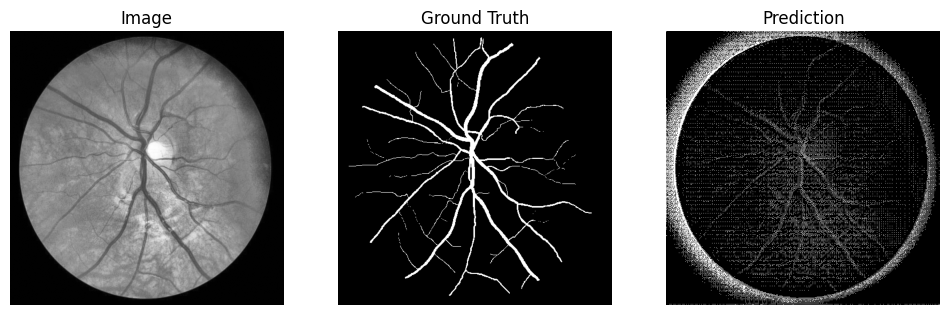

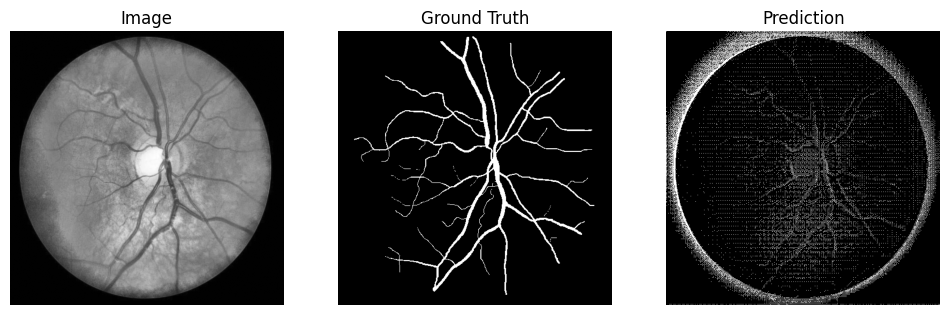

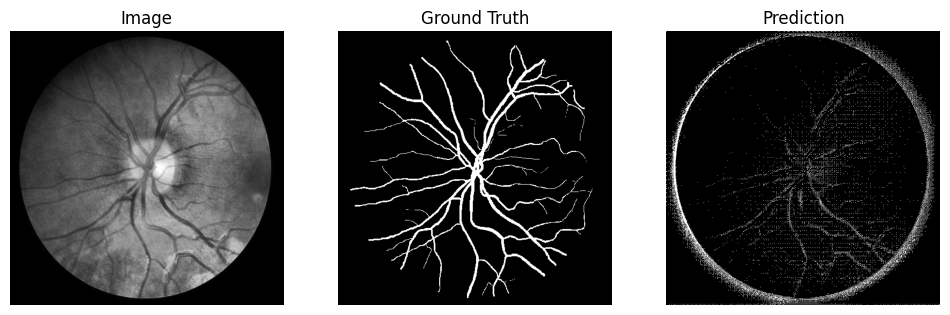

In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.metrics import MeanIoU, Precision, Recall, AUC

# --- Registering Custom Layers ---
@register_keras_serializable()
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, filters, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.ratio = ratio
        self.gap = tf.keras.layers.GlobalAveragePooling2D()
        self.gmp = tf.keras.layers.GlobalMaxPooling2D()
        self.shared_mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal'),
            tf.keras.layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal')
        ])

    def call(self, inputs):
        gap = tf.keras.layers.Reshape((1, 1, self.filters))(self.gap(inputs))
        gmp = tf.keras.layers.Reshape((1, 1, self.filters))(self.gmp(inputs))
        return inputs * (self.shared_mlp(gap) + self.shared_mlp(gmp))

@register_keras_serializable()
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.conv = tf.keras.layers.Conv2D(1, kernel_size, padding='same', activation='sigmoid')

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        return inputs * self.conv(tf.concat([avg_pool, max_pool], axis=-1))

@register_keras_serializable()
class HybridAttention(tf.keras.layers.Layer):
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
        self.kernel_size = kernel_size

    def build(self, input_shape):
        filters = input_shape[-1]
        self.channel = ChannelAttention(filters, self.ratio)
        self.spatial = SpatialAttention(self.kernel_size)

    def call(self, inputs):
        x = self.channel(inputs)
        return self.spatial(x)

# --- Registering Loss Functions ---
@register_keras_serializable()
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

@register_keras_serializable()
def focal_loss(y_true, y_pred, gamma=2., alpha=0.25):
    y_true = tf.cast(y_true, tf.float32)
    epsilon = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    cross_entropy = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
    weight = alpha * y_true * tf.pow(1 - y_pred, gamma) + (1 - alpha) * (1 - y_true) * tf.pow(y_pred, gamma)
    return tf.reduce_mean(weight * cross_entropy)

@register_keras_serializable()
def combined_loss(y_true, y_pred):
    return 0.5 * dice_loss(y_true, y_pred) + 0.5 * focal_loss(y_true, y_pred)

# --- Paths ---
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/"
MODEL_PATH = os.path.join(BASE_DIR, "hanet_better_final.keras")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
TEST_MASK_DIR = os.path.join(BASE_DIR, "test_masks")
IMG_SIZE = (512, 512)

# --- Load Model ---
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        'HybridAttention': HybridAttention,
        'combined_loss': combined_loss,
        'focal_loss': focal_loss,
        'dice_loss': dice_loss
    }
)

# --- Load and Preprocess Test Data ---
def load_image(path, size):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, size)
    img = img.astype(np.float32) / 255.0
    return np.expand_dims(img, axis=-1)

def load_mask(path, size):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, size)
    mask = (mask > 127).astype(np.float32)
    return np.expand_dims(mask, axis=-1)

test_images = sorted([os.path.join(TEST_IMG_DIR, fname) for fname in os.listdir(TEST_IMG_DIR) if fname.endswith(".png")])
test_masks = sorted([os.path.join(TEST_MASK_DIR, fname) for fname in os.listdir(TEST_MASK_DIR) if fname.endswith(".png")])

X_test = np.array([load_image(img_path, IMG_SIZE) for img_path in test_images])
Y_test = np.array([load_mask(mask_path, IMG_SIZE) for mask_path in test_masks])

print(f"Test images loaded: {X_test.shape}, Test masks loaded: {Y_test.shape}")

# --- Predict and Binarize ---
preds = model.predict(X_test, batch_size=4)
preds_bin = (preds > 0.5).astype(np.float32)

# --- Metrics ---
iou = MeanIoU(num_classes=2)
precision = Precision()
recall = Recall()
auc = AUC()

iou.update_state(Y_test, preds_bin)
precision.update_state(Y_test, preds_bin)
recall.update_state(Y_test, preds_bin)
auc.update_state(Y_test, preds)

# Flatten for sklearn
y_true_flat = Y_test.flatten()
y_pred_flat = preds_bin.flatten()

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true_flat, y_pred_flat).ravel()

# Custom metrics
accuracy = accuracy_score(y_true_flat, y_pred_flat)
specificity = tn / (tn + fp)
f1 = f1_score(y_true_flat, y_pred_flat)

print("\n--- Evaluation Metrics ---")
print(f"Accuracy      : {accuracy:.4f}")
print(f"Mean IoU      : {iou.result().numpy():.4f}")
print(f"AUC           : {auc.result().numpy():.4f}")
print(f"Sensitivity   : {recall.result().numpy():.4f}")
print(f"Specificity   : {specificity:.4f}")
print(f"Precision     : {precision.result().numpy():.4f}")
print(f"F1 Score      : {f1:.4f}")

# --- Visualize Results ---
def display_sample(i):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title("Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(Y_test[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(preds_bin[i].squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

    plt.show()

# Show first 3 samples
for i in range(3):
    display_sample(i)


----- ATTENTION PSP EVALUATION

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 90 variables whereas the saved optimizer has 86 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 86 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test images loaded: (8, 512, 512, 1), Test masks loaded: (8, 512, 512, 1)
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step

--- Evaluation Metrics ---
Accuracy      : 0.9570
Mean IoU      : 0.6744
AUC           : 0.9518
Sensitivity   : 0.4418
Specificity   : 0.9917
Precision     : 0.7808
F1 Score      : 0.5643


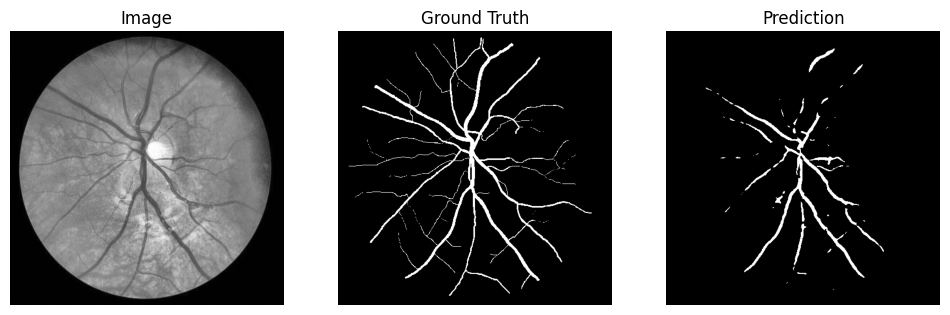

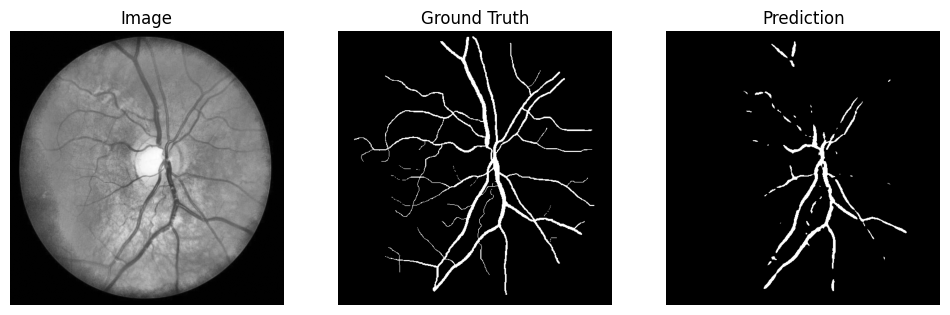

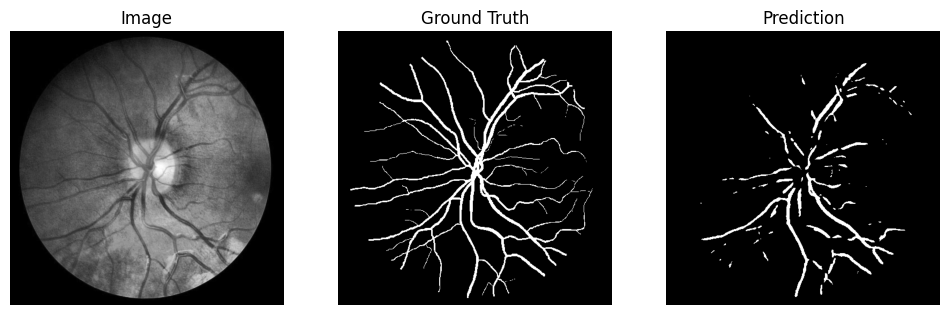

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 90 variables whereas the saved optimizer has 86 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 86 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test images loaded: (8, 512, 512, 1), Test masks loaded: (8, 512, 512, 1)
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step

--- Evaluation Metrics ---
Accuracy      : 0.9570
Mean IoU      : 0.6744
AUC           : 0.9518
Sensitivity   : 0.4418
Specificity   : 0.9917
Precision     : 0.7808
F1 Score      : 0.5643


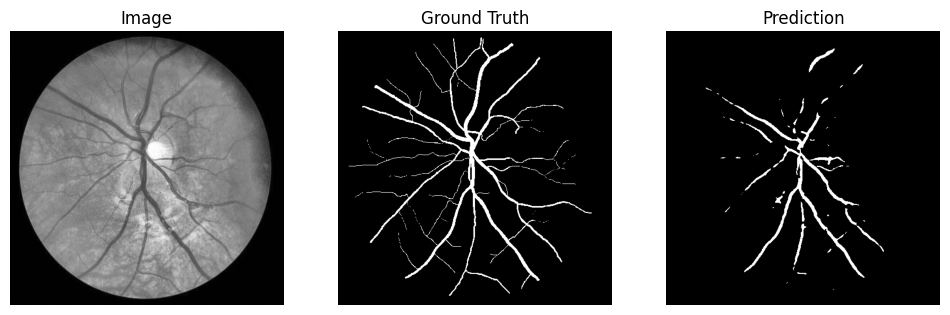

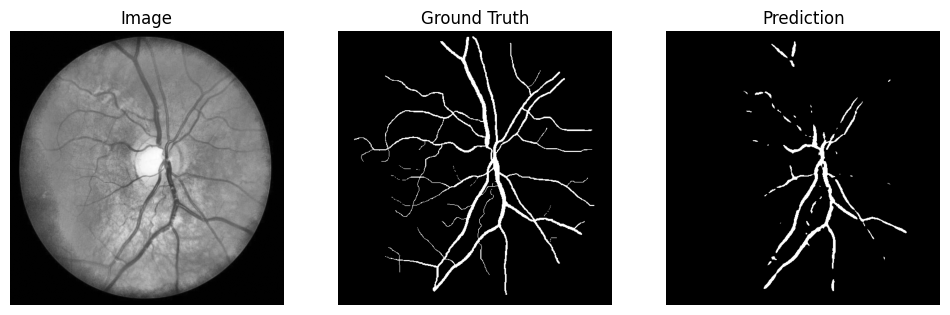

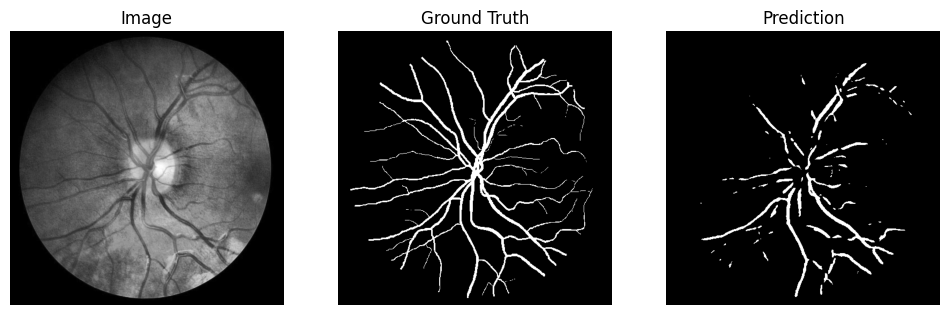

In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.metrics import MeanIoU, Precision, Recall, AUC
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

# --- Paths ---
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed"
MODEL_PATH = os.path.join(BASE_DIR, "retinal_vessel_segmentation_saunet.keras")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
TEST_MASK_DIR = os.path.join(BASE_DIR, "test_masks")
IMG_SIZE = (512, 512)

# Verify directories exist
if not os.path.exists(TEST_IMG_DIR):
    raise FileNotFoundError(f"Test image directory not found: {TEST_IMG_DIR}")
if not os.path.exists(TEST_MASK_DIR):
    raise FileNotFoundError(f"Test mask directory not found: {TEST_MASK_DIR}")

# Check if directories contain files
if not os.listdir(TEST_IMG_DIR) or not os.listdir(TEST_MASK_DIR):
    raise ValueError("Test image or mask directory is empty!")

# --- Load Model ---
model = tf.keras.models.load_model(MODEL_PATH)

# --- Load and Preprocess Test Data ---
def load_image(path, size):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to load image: {path}")
    img = cv2.resize(img, size)
    img = img.astype(np.float32) / 255.0
    return np.expand_dims(img, axis=-1)

def load_mask(path, size):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Failed to load mask: {path}")
    mask = cv2.resize(mask, size)
    mask = (mask > 127).astype(np.float32)
    return np.expand_dims(mask, axis=-1)

test_images = sorted([os.path.join(TEST_IMG_DIR, fname) for fname in os.listdir(TEST_IMG_DIR) if fname.endswith(".png")])
test_masks = sorted([os.path.join(TEST_MASK_DIR, fname) for fname in os.listdir(TEST_MASK_DIR) if fname.endswith(".png")])

# Verify file counts match
if len(test_images) != len(test_masks):
    raise ValueError(f"Mismatched files: {len(test_images)} images vs {len(test_masks)} masks")

X_test = np.array([load_image(img_path, IMG_SIZE) for img_path in test_images])
Y_test = np.array([load_mask(mask_path, IMG_SIZE) for mask_path in test_masks])

# Check if any data was loaded
if X_test.shape[0] == 0 or Y_test.shape[0] == 0:
    raise ValueError("No valid test data found! Check your test directories.")

print(f"Test images loaded: {X_test.shape}, Test masks loaded: {Y_test.shape}")

# --- Predict and Binarize ---
preds = model.predict(X_test, batch_size=4)
preds_bin = (preds > 0.5).astype(np.float32)

# --- Metrics ---
iou = MeanIoU(num_classes=2)
precision = Precision()
recall = Recall()
auc = AUC()

iou.update_state(Y_test, preds_bin)
precision.update_state(Y_test, preds_bin)
recall.update_state(Y_test, preds_bin)
auc.update_state(Y_test, preds)

# Flatten for sklearn
y_true_flat = Y_test.flatten()
y_pred_flat = preds_bin.flatten()

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true_flat, y_pred_flat).ravel()

# Custom metrics
accuracy = accuracy_score(y_true_flat, y_pred_flat)
specificity = tn / (tn + fp)
f1 = f1_score(y_true_flat, y_pred_flat)

print("\n--- Evaluation Metrics ---")
print(f"Accuracy      : {accuracy:.4f}")
print(f"Mean IoU      : {iou.result().numpy():.4f}")
print(f"AUC           : {auc.result().numpy():.4f}")
print(f"Sensitivity   : {recall.result().numpy():.4f}")
print(f"Specificity   : {specificity:.4f}")
print(f"Precision     : {precision.result().numpy():.4f}")
print(f"F1 Score      : {f1:.4f}")

# --- Visualize Results ---
def display_sample(i):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title("Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(Y_test[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(preds_bin[i].squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

    plt.show()

# Show first 3 samples
for i in range(min(3, len(X_test))):
    display_sample(i)


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 98 variables whereas the saved optimizer has 94 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 94 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test images loaded: (8, 512, 512, 1), Test masks loaded: (8, 512, 512, 1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 335ms/step

--- Evaluation Metrics ---
Accuracy      : 0.9517
Mean IoU      : 0.6078
AUC           : 0.9556
Sensitivity   : 0.2757
Specificity   : 0.9972
Precision     : 0.8697
F1 Score      : 0.4186


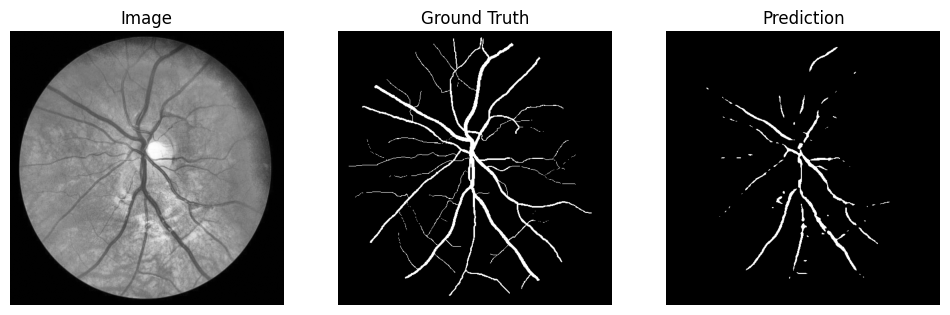

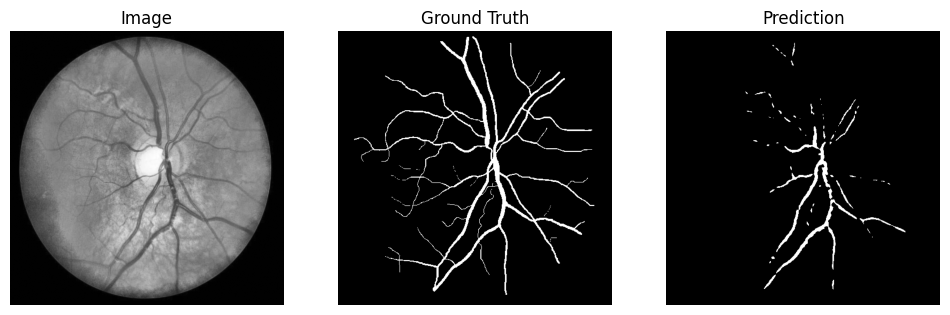

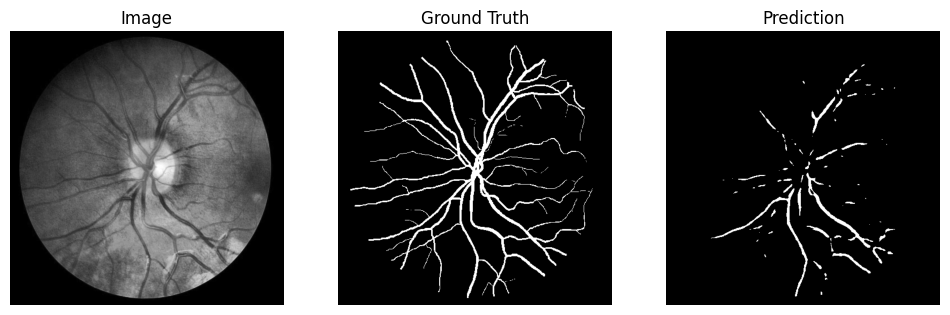

In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.metrics import MeanIoU, Precision, Recall, AUC
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

# --- Paths ---
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed"
MODEL_PATH = os.path.join(BASE_DIR, "saunet.keras")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
TEST_MASK_DIR = os.path.join(BASE_DIR, "test_masks")
IMG_SIZE = (512, 512)

# Verify directories exist
if not os.path.exists(TEST_IMG_DIR):
    raise FileNotFoundError(f"Test image directory not found: {TEST_IMG_DIR}")
if not os.path.exists(TEST_MASK_DIR):
    raise FileNotFoundError(f"Test mask directory not found: {TEST_MASK_DIR}")

# Check if directories contain files
if not os.listdir(TEST_IMG_DIR) or not os.listdir(TEST_MASK_DIR):
    raise ValueError("Test image or mask directory is empty!")

# --- Load Model ---
model = tf.keras.models.load_model(MODEL_PATH)

# --- Load and Preprocess Test Data ---
def load_image(path, size):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to load image: {path}")
    img = cv2.resize(img, size)
    img = img.astype(np.float32) / 255.0
    return np.expand_dims(img, axis=-1)

def load_mask(path, size):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Failed to load mask: {path}")
    mask = cv2.resize(mask, size)
    mask = (mask > 127).astype(np.float32)
    return np.expand_dims(mask, axis=-1)

test_images = sorted([os.path.join(TEST_IMG_DIR, fname) for fname in os.listdir(TEST_IMG_DIR) if fname.endswith(".png")])
test_masks = sorted([os.path.join(TEST_MASK_DIR, fname) for fname in os.listdir(TEST_MASK_DIR) if fname.endswith(".png")])

# Verify file counts match
if len(test_images) != len(test_masks):
    raise ValueError(f"Mismatched files: {len(test_images)} images vs {len(test_masks)} masks")

X_test = np.array([load_image(img_path, IMG_SIZE) for img_path in test_images])
Y_test = np.array([load_mask(mask_path, IMG_SIZE) for mask_path in test_masks])

# Check if any data was loaded
if X_test.shape[0] == 0 or Y_test.shape[0] == 0:
    raise ValueError("No valid test data found! Check your test directories.")

print(f"Test images loaded: {X_test.shape}, Test masks loaded: {Y_test.shape}")

# --- Predict and Binarize ---
preds = model.predict(X_test, batch_size=4)
preds_bin = (preds > 0.5).astype(np.float32)

# --- Metrics ---
iou = MeanIoU(num_classes=2)
precision = Precision()
recall = Recall()
auc = AUC()

iou.update_state(Y_test, preds_bin)
precision.update_state(Y_test, preds_bin)
recall.update_state(Y_test, preds_bin)
auc.update_state(Y_test, preds)

# Flatten for sklearn
y_true_flat = Y_test.flatten()
y_pred_flat = preds_bin.flatten()

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true_flat, y_pred_flat).ravel()

# Custom metrics
accuracy = accuracy_score(y_true_flat, y_pred_flat)
specificity = tn / (tn + fp)
f1 = f1_score(y_true_flat, y_pred_flat)

print("\n--- Evaluation Metrics ---")
print(f"Accuracy      : {accuracy:.4f}")
print(f"Mean IoU      : {iou.result().numpy():.4f}")
print(f"AUC           : {auc.result().numpy():.4f}")
print(f"Sensitivity   : {recall.result().numpy():.4f}")
print(f"Specificity   : {specificity:.4f}")
print(f"Precision     : {precision.result().numpy():.4f}")
print(f"F1 Score      : {f1:.4f}")

# --- Visualize Results ---
def display_sample(i):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title("Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(Y_test[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(preds_bin[i].squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

    plt.show()

# Show first 3 samples
for i in range(min(3, len(X_test))):
    display_sample(i)


In [ ]:
import os

MODEL_PATH = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/complex_iterative_unet_final.keras"
print("File exists:", os.path.exists(MODEL_PATH))


File exists: False


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm
import keras
from tensorflow.keras import layers, Model

# Enable unsafe deserialization
keras.config.enable_unsafe_deserialization()

# ------------------------
# Paths and Setup
# ------------------------
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/"
MODEL_PATH = os.path.join(BASE_DIR, "complex_iterative_unet_final.keras")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
TEST_MASK_DIR = os.path.join(BASE_DIR, "test_masks")
IMG_SIZE = (512, 512)
BATCH_SIZE = 8
ITERATIONS = 3  # Match your training script
DROPOUT_RATE = 0.3  # Match your training script

# ------------------------
# Custom Losses
# ------------------------
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def combined_loss(y_true, y_pred):
    dice = dice_loss(y_true, y_pred)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.7 * dice + 0.3 * bce

# ------------------------
# Custom Lambda Layer
# ------------------------
class CustomLambda(layers.Lambda):
    def __init__(self, function, output_shape, **kwargs):
        super(CustomLambda, self).__init__(function, **kwargs)
        self.custom_output_shape = output_shape

    def compute_output_shape(self, input_shape):
        return self.custom_output_shape(input_shape)

def expand_dims_lambda(x):
    return tf.expand_dims(x, axis=1)

def expand_dims_output_shape(input_shape):
    return (input_shape[0], 1) + input_shape[1:]

# ------------------------
# Model Reconstruction
# ------------------------
def attention_gate(g, s, filters):
    wg = layers.Conv2D(filters, (1, 1), padding='same')(g)
    ws = layers.Conv2D(filters, (1, 1), padding='same')(s)
    out = layers.Activation('relu')(layers.Add()([wg, ws]))
    out = layers.Conv2D(1, (1, 1), padding='same')(out)
    out = layers.Activation('sigmoid')(out)
    return layers.Multiply()([s, out])

def residual_block(x, filters, kernel_size=(3, 3)):
    r = layers.Conv2D(filters, kernel_size, padding='same', activation='relu')(x)
    r = layers.BatchNormalization()(r)
    r = layers.Conv2D(filters, kernel_size, padding='same')(r)
    r = layers.BatchNormalization()(r)
    return layers.Add()([x, r])

def complex_iterative_unet_model(input_size=(512, 512, 1), iterations=ITERATIONS):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    c1 = residual_block(c1, 64)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(p1)
    c2 = residual_block(c2, 128)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(p2)
    c3 = residual_block(c3, 256)
    c3 = layers.BatchNormalization()(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(p3)
    c4 = residual_block(c4, 512)
    c4 = layers.BatchNormalization()(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, (3, 3), dilation_rate=2, padding='same', activation='relu')(p4)
    c5 = residual_block(c5, 1024)
    c5 = layers.Dropout(DROPOUT_RATE)(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    att6 = attention_gate(u6, c4, 512)
    u6 = layers.concatenate([u6, att6])
    c6 = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(u6)
    c6 = residual_block(c6, 512)
    c6 = layers.BatchNormalization()(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    att7 = attention_gate(u7, c3, 256)
    u7 = layers.concatenate([u7, att7])
    c7 = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(u7)
    c7 = residual_block(c7, 256)
    c7 = layers.BatchNormalization()(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    att8 = attention_gate(u8, c2, 128)
    u8 = layers.concatenate([u8, att8])
    c8 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(u8)
    c8 = residual_block(c8, 128)
    c8 = layers.BatchNormalization()(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    att9 = attention_gate(u9, c1, 64)
    u9 = layers.concatenate([u9, att9])
    c9 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(u9)
    c9 = residual_block(c9, 64)
    c9 = layers.BatchNormalization()(c9)

    # Initial prediction
    initial_pred = layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same')(c9)

    # Iterative refinement with ConvLSTM
    refinement_input = layers.concatenate([inputs, initial_pred])
    refinement_input_expanded = CustomLambda(
        expand_dims_lambda,
        output_shape=expand_dims_output_shape
    )(refinement_input)
    refinement = layers.ConvLSTM2D(64, (3, 3), padding='same', return_sequences=False)(refinement_input_expanded)

    for _ in range(iterations - 1):
        att_ref = attention_gate(refinement, inputs, 64)
        att_ref_expanded = CustomLambda(
            expand_dims_lambda,
            output_shape=expand_dims_output_shape
        )(att_ref)
        refinement = layers.ConvLSTM2D(64, (3, 3), padding='same', return_sequences=False)(att_ref_expanded)

    # Multi-scale output fusion
    out1 = layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same')(refinement)
    out2 = layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same')(c9)
    outputs = layers.Average()([out1, out2])

    outputs = layers.Activation('sigmoid', dtype='float32')(outputs)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# ------------------------
# Load Test Dataset
# ------------------------
def parse_image(img_path, mask_path):
    try:
        img = tf.io.read_file(img_path)
        img = tf.image.decode_image(img, channels=1, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0

        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
        mask = tf.image.resize(mask, IMG_SIZE)
        mask = tf.cast(mask, tf.float32) / 255.0

        return img, mask
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        raise

def get_file_paths(image_dir, mask_dir):
    image_files = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir) if fname.endswith('.png')])
    if len(image_files) != len(mask_files):
        raise ValueError(f"Mismatch in number of images ({len(image_files)}) and masks ({len(mask_files)})")
    return image_files, mask_files

def create_dataset(img_paths, mask_paths, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    dataset = dataset.map(lambda img, mask: parse_image(img, mask), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

try:
    test_img_paths, test_mask_paths = get_file_paths(TEST_IMG_DIR, TEST_MASK_DIR)  # Fixed typo here
    print(f"Found {len(test_img_paths)} test images and {len(test_mask_paths)} masks")
    test_dataset = create_dataset(test_img_paths, test_mask_paths, BATCH_SIZE)
except Exception as e:
    print(f"Error loading dataset: {e}")
    raise

# ------------------------
# Load Model and Weights
# ------------------------
try:
    # Reconstruct the model
    model = complex_iterative_unet_model(input_size=(512, 512, 1), iterations=ITERATIONS)
    # Load weights from the saved model
    model.load_weights(MODEL_PATH)
    print("Model reconstructed and weights loaded successfully")
except Exception as e:
    print(f"Error loading model/weights: {e}")
    raise

# ------------------------
# Evaluation Metrics
# ------------------------
def compute_metrics(y_true, y_pred, threshold=0.5, smooth=1e-6):
    y_pred_bin = (y_pred > threshold).astype(np.uint8)
    y_true = y_true.astype(np.uint8)

    y_true_flat = y_true.ravel()
    y_pred_flat = y_pred_bin.ravel()

    tp = np.sum(y_true_flat * y_pred_flat)
    fp = np.sum((1 - y_true_flat) * y_pred_flat)
    fn = np.sum(y_true_flat * (1 - y_pred_flat))
    tn = np.sum((1 - y_true_flat) * (1 - y_pred_flat))

    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou = (tp + smooth) / (tp + fp + fn + smooth)
    accuracy = (tp + tn) / (tp + tn + fp + fn + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    recall = (tp + smooth) / (tp + fn + smooth)
    specificity = (tn + smooth) / (tn + fp + smooth)
    f1 = (2 * precision * recall) / (precision + recall + smooth)

    return {
        "Dice": dice,
        "IoU": iou,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1
    }

# ------------------------
# Prediction and Evaluation
# ------------------------
def evaluate_model(model, dataset):
    y_trues = []
    y_preds = []

    for imgs, masks in tqdm(dataset, desc="Evaluating"):
        try:
            preds = model.predict(imgs, verbose=0)
            y_preds.append(preds)
            y_trues.append(masks.numpy())
        except Exception as e:
            print(f"Error during prediction: {e}")
            continue

    if not y_trues:
        raise ValueError("No valid predictions were made")

    y_true = np.concatenate(y_trues, axis=0)
    y_pred = np.concatenate(y_preds, axis=0)

    if y_true.shape[-1] == 1:
        y_true = y_true.squeeze(-1)
        y_pred = y_pred.squeeze(-1)

    metrics = compute_metrics(y_true, y_pred)
    return metrics

# Run evaluation
try:
    metrics = evaluate_model(model, test_dataset)
    print("\n--- Evaluation Metrics ---")
    for metric, value in metrics.items():
        print(f"{metric:<12} : {value:.4f}")
except Exception as e:
    print(f"Error during evaluation: {e}")

Found 8 test images and 8 masks
Model reconstructed and weights loaded successfully


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_714']
Received: inputs=Tensor(shape=(8, 512, 512, 1))
  warnings.warn(msg)
Evaluating: 100%|██████████| 1/1 [01:10<00:00, 70.38s/it]


--- Evaluation Metrics ---
Dice         : 0.1186
IoU          : 0.0630
Accuracy     : 0.0630
Precision    : 0.0630
Recall       : 1.0000
Specificity  : 0.0000
F1           : 0.1186


Test images loaded: (8, 512, 512, 1), Test masks loaded: (8, 512, 512, 1)
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step

--- Evaluation Metrics ---
Accuracy      : 0.9432
Mean IoU      : 0.5257
AUC           : 0.9408
Sensitivity   : 0.1100
Specificity   : 0.9992
Precision     : 0.9036
F1 Score      : 0.1961


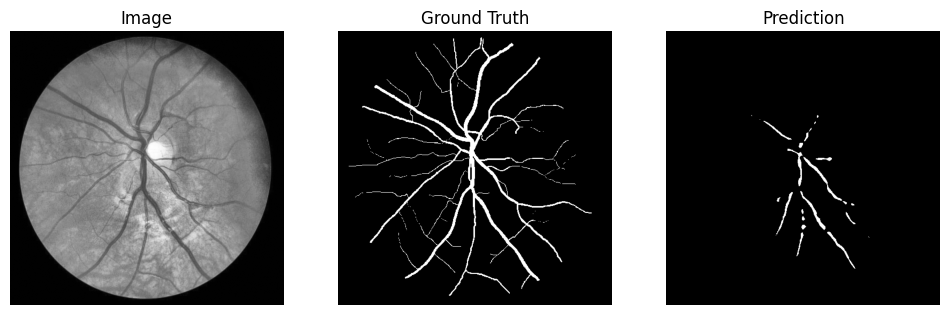

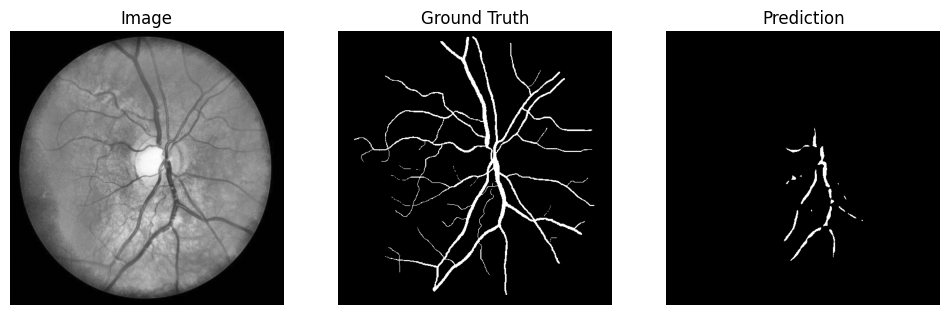

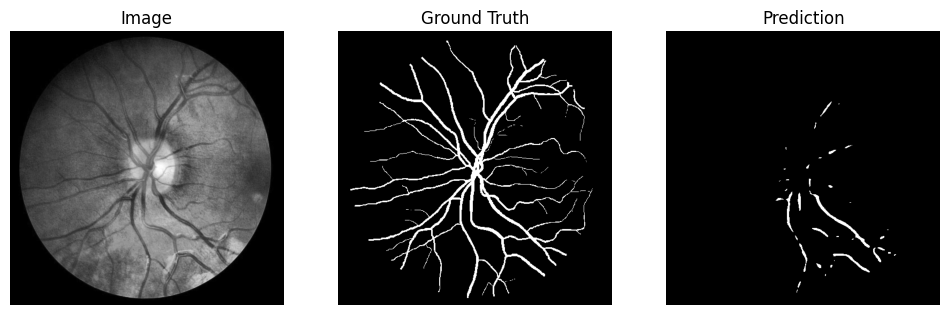

In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.metrics import MeanIoU, Precision, Recall, AUC
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

# --- Paths ---
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed"
MODEL_PATH = os.path.join(BASE_DIR, "SDnet_model.keras")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
TEST_MASK_DIR = os.path.join(BASE_DIR, "test_masks")
IMG_SIZE = (512, 512)

# Verify directories exist
if not os.path.exists(TEST_IMG_DIR):
    raise FileNotFoundError(f"Test image directory not found: {TEST_IMG_DIR}")
if not os.path.exists(TEST_MASK_DIR):
    raise FileNotFoundError(f"Test mask directory not found: {TEST_MASK_DIR}")

# Check if directories contain files
if not os.listdir(TEST_IMG_DIR) or not os.listdir(TEST_MASK_DIR):
    raise ValueError("Test image or mask directory is empty!")

# --- Load Model ---
model = tf.keras.models.load_model(MODEL_PATH)

# --- Load and Preprocess Test Data ---
def load_image(path, size):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to load image: {path}")
    img = cv2.resize(img, size)
    img = img.astype(np.float32) / 255.0
    return np.expand_dims(img, axis=-1)

def load_mask(path, size):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Failed to load mask: {path}")
    mask = cv2.resize(mask, size)
    mask = (mask > 127).astype(np.float32)
    return np.expand_dims(mask, axis=-1)

test_images = sorted([os.path.join(TEST_IMG_DIR, fname) for fname in os.listdir(TEST_IMG_DIR) if fname.endswith(".png")])
test_masks = sorted([os.path.join(TEST_MASK_DIR, fname) for fname in os.listdir(TEST_MASK_DIR) if fname.endswith(".png")])

# Verify file counts match
if len(test_images) != len(test_masks):
    raise ValueError(f"Mismatched files: {len(test_images)} images vs {len(test_masks)} masks")

X_test = np.array([load_image(img_path, IMG_SIZE) for img_path in test_images])
Y_test = np.array([load_mask(mask_path, IMG_SIZE) for mask_path in test_masks])

# Check if any data was loaded
if X_test.shape[0] == 0 or Y_test.shape[0] == 0:
    raise ValueError("No valid test data found! Check your test directories.")

print(f"Test images loaded: {X_test.shape}, Test masks loaded: {Y_test.shape}")

# --- Predict and Binarize ---
preds = model.predict(X_test, batch_size=4)
preds_bin = (preds > 0.5).astype(np.float32)

# --- Metrics ---
iou = MeanIoU(num_classes=2)
precision = Precision()
recall = Recall()
auc = AUC()

iou.update_state(Y_test, preds_bin)
precision.update_state(Y_test, preds_bin)
recall.update_state(Y_test, preds_bin)
auc.update_state(Y_test, preds)

# Flatten for sklearn
y_true_flat = Y_test.flatten()
y_pred_flat = preds_bin.flatten()

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true_flat, y_pred_flat).ravel()

# Custom metrics
accuracy = accuracy_score(y_true_flat, y_pred_flat)
specificity = tn / (tn + fp)
f1 = f1_score(y_true_flat, y_pred_flat)

print("\n--- Evaluation Metrics ---")
print(f"Accuracy      : {accuracy:.4f}")
print(f"Mean IoU      : {iou.result().numpy():.4f}")
print(f"AUC           : {auc.result().numpy():.4f}")
print(f"Sensitivity   : {recall.result().numpy():.4f}")
print(f"Specificity   : {specificity:.4f}")
print(f"Precision     : {precision.result().numpy():.4f}")
print(f"F1 Score      : {f1:.4f}")

# --- Visualize Results ---
def display_sample(i):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title("Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(Y_test[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(preds_bin[i].squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

    plt.show()

# Show first 3 samples
for i in range(min(3, len(X_test))):
    display_sample(i)


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Conv2DTranspose, concatenate, SpatialDropout2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Configuration
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/"
TRAIN_IMG_DIR = os.path.join(BASE_DIR, "augmented_train_images")
TRAIN_MASK_DIR = os.path.join(BASE_DIR, "augmented_train_masks")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test_images")
TEST_MASK_DIR = os.path.join(BASE_DIR, "test_masks")

BATCH_SIZE = 8
IMG_SIZE = (512, 512)
EPOCHS = 30

# Data Loader
class RetinalDataset(tf.keras.utils.Sequence):
    def __init__(self, image_dir, mask_dir, batch_size=8, shuffle=True):
        self.image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir)])
        self.mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, index):
        batch_images = []
        batch_masks = []

        for i in range(index*self.batch_size, (index+1)*self.batch_size):
            img = cv2.imread(self.image_paths[i], cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(self.mask_paths[i], cv2.IMREAD_GRAYSCALE)

            # Normalize and add channel dimension
            img = np.expand_dims(img / 255.0, axis=-1)
            mask = np.expand_dims((mask > 127).astype(np.float32), axis=-1)

            batch_images.append(img)
            batch_masks.append(mask)

        return np.array(batch_images), np.array(batch_masks)

    def on_epoch_end(self):
        self.indices = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

# SD-UNet Model
def build_sd_unet():
    inputs = Input((512, 512, 1))

    # Encoder
    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = MaxPool2D()(c1)
    p1 = SpatialDropout2D(0.2)(p1)

    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = MaxPool2D()(c2)
    p2 = SpatialDropout2D(0.2)(p2)

    # Bottleneck
    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)

    # Decoder
    u1 = Conv2DTranspose(128, 2, strides=2, padding='same')(c3)
    u1 = concatenate([u1, c2])
    c4 = Conv2D(128, 3, activation='relu', padding='same')(u1)
    c4 = Conv2D(128, 3, activation='relu', padding='same')(c4)

    u2 = Conv2DTranspose(64, 2, strides=2, padding='same')(c4)
    u2 = concatenate([u2, c1])
    c5 = Conv2D(64, 3, activation='relu', padding='same')(u2)
    c5 = Conv2D(64, 3, activation='relu', padding='same')(c5)

    outputs = Conv2D(1, 1, activation='sigmoid')(c5)

    return Model(inputs, outputs)

# Training function
def train_and_save_model():
    # Create datasets
    train_dataset = RetinalDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, BATCH_SIZE)
    val_dataset = RetinalDataset(TEST_IMG_DIR, TEST_MASK_DIR, BATCH_SIZE, shuffle=False)

    # Build model
    model = build_sd_unet()
    model.compile(optimizer=Adam(1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    # Callbacks
    callbacks = [
        ModelCheckpoint('best_retinal_model.keras',
                        monitor='val_accuracy',
                        save_best_only=True,
                        verbose=1),
        EarlyStopping(patience=15,
                     monitor='val_loss',
                     restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss',
                         factor=0.2,
                         patience=5,
                         verbose=1)
    ]

    # Train model
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=callbacks
    )

    # Save final model
    model.save("/content/drive/MyDrive/Colab_Notebooks/chase/preprocessed/SDnet_model.keras")
    print("Model saved as final_retinal_model.keras")

    return history

# Run training
if __name__ == "__main__":
    train_and_save_model()


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 998ms/step - accuracy: 0.8314 - loss: 0.6830
Epoch 1: val_accuracy improved from -inf to 0.93696, saving model to best_retinal_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.8371 - loss: 0.6820 - val_accuracy: 0.9370 - val_loss: 0.6416 - learning_rate: 1.0000e-04
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9311 - loss: 0.5928
Epoch 2: val_accuracy did not improve from 0.93696
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9308 - loss: 0.5879 - val_accuracy: 0.9370 - val_loss: 0.3897 - learning_rate: 1.0000e-04
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9254 - loss: 0.4184
Epoch 3: val_accuracy did not improve from 0.93696
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9257 - loss: 0.4173 - val_accuracy: 0.9370 - val_loss: 0.3807 - learning_rate: 1.0000e-04
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9287 - loss: 0.3749
Epoch 4: val_accuracy did not improve fr